###Решётка D2Q9
Модель решётки D2Q9 использует 9 скоростей:

$$
\mathbf{e}_i =
\{(-1,1),(0,1),(1,1),(-1,0),(0,0),(1,0),(-1,-1),(0,-1),(1,-1)\}.
$$


Дополнительно задаём:


- $D_{phys}$ — физический диаметр (м)
- $\nu_{phys}$ — физическая кинематическая вязкость (м²/с)
- $D_{lattice}$ — диаметр в узлах (решёточный)




Размер ячейки:

$$
\Delta x_{\text{phys}} = \frac{D_{\text{phys}}}{D_{\text{lattice}}}
$$

Связь вязкостей:

$$
\nu_{\text{phys}} = \nu_{\text{lbm}} \frac{\Delta x_{\text{phys}}^{2}}{\Delta t_{\text{phys}}}
$$

Отсюда масштаб времени:

$$
\Delta t_{\text{phys}} = \nu_{\text{lbm}} \frac{\Delta x_{\text{phys}}^{2}}{\nu_{\text{phys}}}
$$

Теперь физическая скорость:

$$
U_{\text{phys}} = U_{\text{lbm}} \frac{\Delta x_{\text{phys}}}{\Delta t_{\text{phys}}}
= U_{\text{lbm}} \,\frac{\nu_{\text{phys}}}{\nu_{\text{lbm}} \,\Delta x_{\text{phys}}}
$$

Итоговая формула:

$$
U_{\text{phys}} = U_{\text{lbm}} \,\frac{\nu_{\text{phys}}}{\nu_{\text{lbm}} \,\Delta x_{\text{phys}}}
$$


Например, при Re= 100, физическом диаметре равным 0.01 м, и кинематической вязкости, равной 1e-6 м²/с,получается, что физическая скорорсть равна ≈ **0.01 м/с**

In [1]:

import time
import numpy as np
import matplotlib.pyplot as plt, matplotlib.animation
import numba as nb
from numba import vectorize

# Размер канала
Height = 80
Width  = 400

D_lattice = Height // 5
R_lattice = D_lattice // 2
CylinderCenter = (Height // 2,
                  Width  // 4)


D_phys = 0.01
dx_phys = D_phys / D_lattice

Q = 9   # число скоростей
D = 2   # размерность

V = np.array([
    [-1.0,  1.0],
    [ 0.0,  1.0],
    [ 1.0,  1.0],
    [-1.0,  0.0],
    [ 0.0,  0.0],
    [ 1.0,  0.0],
    [-1.0, -1.0],
    [ 0.0, -1.0],
    [ 1.0, -1.0],
], dtype=np.float64)

# Весовые коэффициенты
W = np.array([
    1/36, 1/9, 1/36,
    1/9,  4/9, 1/9,
    1/36, 1/9, 1/36
], dtype=np.float64)

cs = 1.0 / np.sqrt(3.0)   # скорость звука в LBM
cs2 = cs * cs

Vx = V[:, 0].reshape(Q, 1, 1)
Vy = V[:, 1].reshape(Q, 1, 1)
Wb = W.reshape(Q, 1, 1)

Opp = np.array([8, 7, 6, 5, 4, 3, 2, 1, 0], dtype=np.int64)


def make_cylinder_mask():
    mask = np.zeros((Height, Width), dtype=bool)
    cy, cx = CylinderCenter
    for y in range(Height):
        for x in range(Width):
            dy = y - cy
            dx = x - cx
            if dy*dy + dx*dx <= R_lattice*R_lattice:
                mask[y, x] = True
    return mask


def make_solid_mask():
    solid = np.zeros((Height, Width), dtype=bool)
    # было: solid[0, :] = True; solid[-1, :] = True
    # оставляем твёрдой только геометрию цилиндра
    solid |= make_cylinder_mask()
    return solid


solid_mask = make_solid_mask()


###Макроскопические величины, равновесие, столкновения и границы

1.   
   Вычисление плотности и скорости:
   $$
   \rho = \sum_i f_i,\qquad
   \rho \mathbf{u} = \sum_i f_i \mathbf{e}_i.
   $$

2. **Равновесное распределение**:
   $$
   f_i^{eq} = \rho\, w_i
   \left[
   1 + \frac{\mathbf{e}_i\cdot\mathbf{u}}{c_s^2}
   + \frac{(\mathbf{e}_i\cdot\mathbf{u})^2}{2c_s^4}
   - \frac{u^2}{2c_s^2}
   \right].
   $$

3. **Столкновение**  
   $$
   f_i^{new} = f_i + \frac{f_i^{eq} - f_i}{\tau}.
   $$



In [2]:

def macroscopic(f):
    rho = np.sum(f, axis=0)

    rho_safe = rho.copy()
    rho_safe[rho_safe < 1e-8] = 1e-8

    jx = np.sum(f * Vx, axis=0)
    jy = np.sum(f * Vy, axis=0)

    ux = jx / rho_safe
    uy = jy / rho_safe

    ux = np.clip(ux, -0.3, 0.3)
    uy = np.clip(uy, -0.3, 0.3)

    return rho_safe, ux, uy


def equilibrium(ux, uy, rho):
    ux3 = ux[np.newaxis, :, :]
    uy3 = uy[np.newaxis, :, :]
    rho3 = rho[np.newaxis, :, :]

    UV = (Vx * ux3 + Vy * uy3) / cs2
    U2 = (ux*ux + uy*uy) / cs2

    feq = rho3 * Wb * (1.0 + UV + 0.5*UV*UV - 0.5*U2[np.newaxis, :, :])
    return feq


def vorticity(ux, uy):

    duy_dx = np.roll(uy, -1, axis=1) - np.roll(uy, 1, axis=1)
    dux_dy = np.roll(ux, -1, axis=0) - np.roll(ux, 1, axis=0)
    return duy_dx - dux_dy


@vectorize(['float64(float64, float64, float64)'],
           target='parallel', nopython=True)
def collision_update(fi, feq, tau):
    return fi + (feq - fi) / tau


def streaming(f):
    f_stream = np.empty_like(f)
    for q in range(Q):
        vy = int(V[q, 1])
        vx = int(V[q, 0])
        f_stream[q] = np.roll(f[q], shift=(vy, vx), axis=(0, 1))
    return f_stream


def apply_bounce_back(f, solid_mask):
    # Неподвижная твёрдая граница (цилиндр)
    pairs = [(0, 8), (1, 7), (2, 6), (3, 5)]
    for q, qo in pairs:
        f_q   = f[q]
        f_opp = f[qo]
        tmp = f_q[solid_mask].copy()
        f_q[solid_mask]   = f_opp[solid_mask]
        f_opp[solid_mask] = tmp


def apply_zou_he_inlet(f, u_in, v_in, solid_mask):
    x = 0
    fluid = ~solid_mask[:, x]

    if not np.any(fluid):
        return

    fN  = f[1, fluid, x]
    fS  = f[7, fluid, x]
    fW  = f[3, fluid, x]
    fNW = f[0, fluid, x]
    fSW = f[6, fluid, x]
    fC  = f[4, fluid, x]

    rho = (fC + fN + fS + 2.0*(fW + fNW + fSW)) / (1.0 - u_in)

    rho = np.clip(rho, 0.5, 2.0)

    fE_new  = fW  + (2.0/3.0) * rho * u_in
    fNE_new = fSW + 0.5*(fS - fN) + (1.0/6.0)*rho*u_in + 0.5*rho*v_in
    fSE_new = fNW - 0.5*(fS - fN) + (1.0/6.0)*rho*u_in - 0.5*rho*v_in

    f[5, fluid, x] = fE_new
    f[2, fluid, x] = fNE_new
    f[8, fluid, x] = fSE_new


def apply_zou_he_outlet(f, solid_mask):
    xR = Width - 1
    xL = Width - 2

    fluid = ~solid_mask[:, xR]
    if not np.any(fluid):
        return

    f_inner = f[:, fluid, xL]

    rho_inner = np.sum(f_inner, axis=0)
    rho_inner[rho_inner < 1e-8] = 1e-8

    Vx_flat = V[:, 0].reshape(Q, 1)
    Vy_flat = V[:, 1].reshape(Q, 1)

    jx = np.sum(f_inner * Vx_flat, axis=0)
    jy = np.sum(f_inner * Vy_flat, axis=0)

    ux = jx / rho_inner
    uy = jy / rho_inner

    ux = np.clip(ux, -0.3, 0.3)
    uy = np.clip(uy, -0.3, 0.3)

    fN  = f[1, fluid, xR]
    fS  = f[7, fluid, xR]
    fE  = f[5, fluid, xR]
    fNE = f[2, fluid, xR]
    fSE = f[8, fluid, xR]
    fC  = f[4, fluid, xR]

    rho_b = (fC + fN + fS + 2.0*(fE + fNE + fSE)) / (1.0 + ux)

    rho_b = np.clip(rho_b, 0.5, 2.0)

    fW_new  = fE - (2.0/3.0) * rho_b * ux
    fNW_new = fSE + 0.5*(fS - fN) - (1.0/6.0)*rho_b*ux + 0.5*rho_b*uy
    fSW_new = fNE - 0.5*(fS - fN) - (1.0/6.0)*rho_b*ux - 0.5*rho_b*uy

    f[3, fluid, xR] = fW_new
    f[0, fluid, xR] = fNW_new
    f[6, fluid, xR] = fSW_new



Связь между числом Рейнольдса, вязкостью и параметром релаксации:

$$
\nu = c_s^2(\tau - \tfrac12),
\qquad
Re = \frac{U\,D}{\nu}.
$$



In [3]:

def compute_tau_from_Re(Re, U_in, D_char):
    nu_lbm = U_in * D_char / Re
    tau = 0.5 + nu_lbm / cs2
    return tau, nu_lbm


Re_target = 50.0
U_inlet   = 0.05
tau       = 0.6
nu_lbm    = cs2 * (tau - 0.5)
F         = None


def init_simulation(Re=50.0):
    global Re_target, U_inlet, tau, nu_lbm, F

    Re_target = float(Re)

    tau = 0.6
    nu_lbm = cs2 * (tau - 0.5)

    D_char = 2 * R_lattice
    U_inlet = Re_target * nu_lbm / D_char

    # U_inlet = float(np.clip(U_inlet, 0.01, 0.08))

    Re_effective = U_inlet * D_char / nu_lbm

    print("Инициализация: Re_задано = {:.1f}, Re_факт = {:.1f}, "
          "tau = {:.3f}, nu_LBM = {:.5f}, U_inlet = {:.4f}"
          .format(Re_target, Re_effective, tau, nu_lbm, U_inlet))

    rho0 = np.ones((Height, Width), dtype=np.float64)
    ux0  = np.zeros((Height, Width), dtype=np.float64) + U_inlet
    uy0  = np.zeros((Height, Width), dtype=np.float64)

    ux0[solid_mask] = 0.0
    uy0[solid_mask] = 0.0

    F = equilibrium(ux0, uy0, rho0)


def lbm_step(F_in):
    rho, ux, uy = macroscopic(F_in)

    ux[solid_mask] = 0.0
    uy[solid_mask] = 0.0

    feq = equilibrium(ux, uy, rho)
    tau_array = np.full_like(F_in, tau)
    F_post = collision_update(F_in, feq, tau_array)

    F_stream = streaming(F_post)

    apply_bounce_back(F_stream, solid_mask)

    apply_zou_he_inlet(F_stream, u_in=U_inlet, v_in=0.0, solid_mask=solid_mask)
    apply_zou_he_outlet(F_stream, solid_mask=solid_mask)

    return F_stream


###Анимация эволюции завихренности

Завихренность определяется как:
$$
\omega(x,y) =
\frac{\partial u_y}{\partial x}
- \frac{\partial u_x}{\partial y}.
$$



=== Re = 50.0 ===
Инициализация: Re_задано = 50.0, Re_факт = 50.0, tau = 0.600, nu_LBM = 0.03333, U_inlet = 0.1042


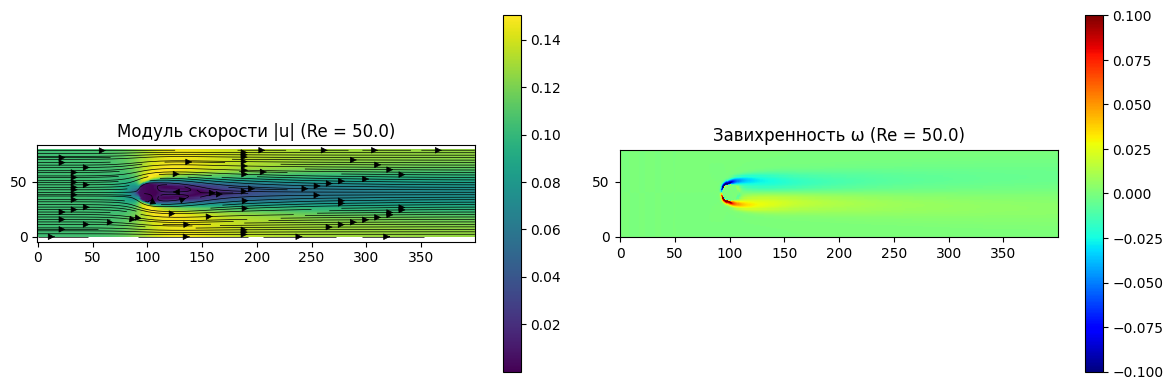


=== Re = 100.0 ===
Инициализация: Re_задано = 100.0, Re_факт = 100.0, tau = 0.600, nu_LBM = 0.03333, U_inlet = 0.2083


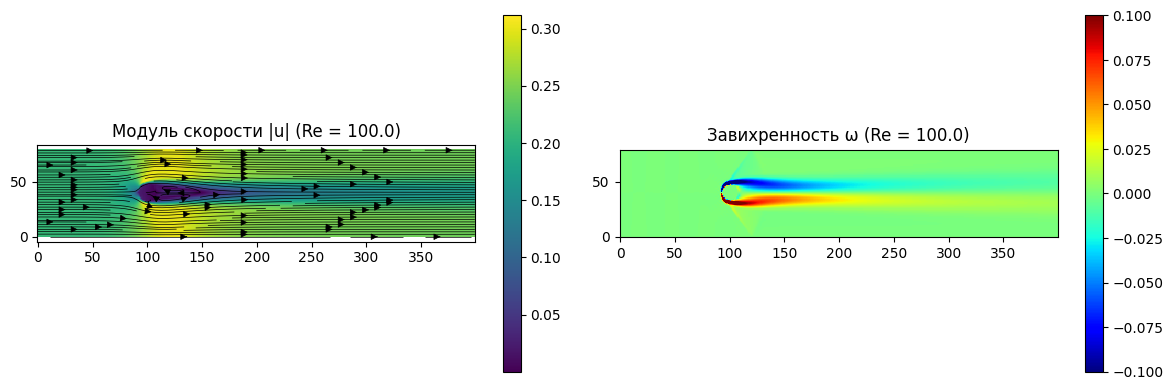


=== Re = 150.0 ===
Инициализация: Re_задано = 150.0, Re_факт = 150.0, tau = 0.600, nu_LBM = 0.03333, U_inlet = 0.3125


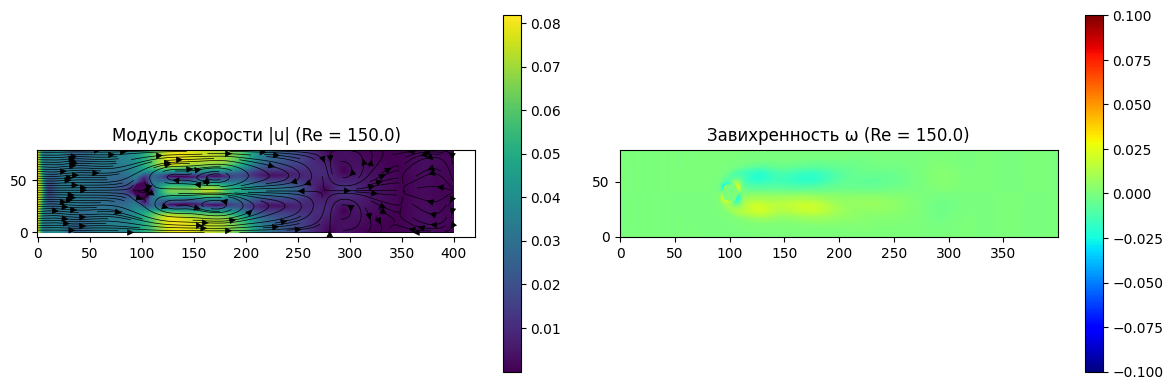

In [4]:
from IPython.display import HTML, display

Re_list = [50, 100, 150]

STEPS_PER_FRAME = 20
NUM_FRAMES = 200
num_relax_steps = 2000

for Re_val in Re_list:
    print(f"\n=== Re = {Re_val:.1f} ===")

    init_simulation(Re=Re_val)

    fig_vort, ax_vort = plt.subplots(figsize=(10, 4))

    rho0, ux0, uy0 = macroscopic(F)
    omega0 = vorticity(ux0, uy0)

    im_vort = ax_vort.imshow(
        omega0,
        origin='lower',
        cmap='jet',
        vmin=-0.1, vmax=0.1,
        interpolation='none'
    )
    ax_vort.set_title(f"Эволюция завихренности ω (Re = {Re_val:.1f})")
    plt.colorbar(im_vort, ax=ax_vort)

    def update_vorticity_frame(frame):
        global F
        for _ in range(STEPS_PER_FRAME):
            F = lbm_step(F)

        rho, ux, uy = macroscopic(F)
        omega = vorticity(ux, uy)
        im_vort.set_array(omega)
        return (im_vort,)

    anim_vort = matplotlib.animation.FuncAnimation(
        fig_vort,
        update_vorticity_frame,
        frames=NUM_FRAMES,
        blit=True
    )

    display(HTML(anim_vort.to_html5_video()))
    plt.close(fig_vort)

    for _ in range(num_relax_steps):
        F = lbm_step(F)

    rho_ss, ux_ss, uy_ss = macroscopic(F)
    speed = np.sqrt(ux_ss**2 + uy_ss**2)
    omega_ss = vorticity(ux_ss, uy_ss)

    Y, X = np.mgrid[0:Height, 0:Width]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # |u|
    ax0 = axes[0]
    im_speed = ax0.imshow(
        speed,
        origin='lower',
        cmap='viridis',
        interpolation='none'
    )
    ax0.set_title(f"Модуль скорости |u| (Re = {Re_val:.1f})")
    plt.colorbar(im_speed, ax=ax0)

    ax0.streamplot(
        X, Y, ux_ss, uy_ss,
        color='k',
        density=1.2,
        linewidth=0.5
    )

    # ω
    ax1 = axes[1]
    im_omega = ax1.imshow(
        omega_ss,
        origin='lower',
        cmap='jet',
        vmin=-0.1, vmax=0.1,
        interpolation='none'
    )
    ax1.set_title(f"Завихренность ω (Re = {Re_val:.1f})")
    plt.colorbar(im_omega, ax=ax1)

    plt.tight_layout()
    plt.show()
